In [19]:
import pandas as pd
import seaborn as sns
import numpy as np
import re
import matplotlib.pyplot as plt
import numpy as np


font = {'family':'helvetica neue',
            'color':  'black',
            'weight': 'bold',
            'size': 12
            }
rs={'family':'helvetica neue',
    'size':12
   }


import matplotlib.cm as cm
import matplotlib.colors as colors

In [20]:
bb_shift_data=pd.read_csv('../../../data/dihedrals/rotamer_shift/BACKBONE_ROTAMER_SHIFT_PRE_VS_UNB.csv',
                         index_col=0)
bb_shift_data

,Residues,psi shift,phi shift,Max,Max BB
0,1,0.297036,0.004662,0.297036,psi
1,2,0.324675,0.000000,0.324675,psi
2,3,0.101898,0.137196,0.137196,phi
3,4,0.013653,0.007659,0.013653,psi
4,5,0.012987,0.012321,0.012987,psi
...,...,...,...,...,...
114,115,0.190143,0.001665,0.190143,psi
115,116,0.026307,0.000999,0.026307,psi
116,117,0.360972,0.060606,0.360972,psi
117,118,0.120879,0.056943,0.120879,psi


In [21]:
chi_shift_select_df=pd.read_csv('../../../data/dihedrals/rotamer_shift/SIDECHAIN_ROTAMER_SHIFT_PRE_VS_UNB.csv',
                               index_col=0)
chi_shift_select_df


,CHI1,CHI2,CHI3,CHI4,RESIDUES
0,0.357198,0.479076,0.124542,0.00000,1
1,0.521257,0.522367,0.000000,0.00000,2
2,0.224220,0.000000,0.000000,0.00000,3
3,0.456654,0.585859,0.015318,0.00000,4
4,0.138972,0.256410,0.090354,0.28194,5
...,...,...,...,...,...
114,0.220890,0.000000,0.000000,0.00000,115
115,0.098124,0.056388,0.321900,0.00000,116
116,0.484404,0.195138,0.139638,0.00000,117
117,0.192918,0.000000,0.000000,0.00000,118


In [22]:
max(bb_shift_data["Max"]), max(chi_shift_select_df["CHI1"])

(0.6257076257076257, 0.6282606282606282)

/var/folders/pp/z1pgcq157pjgg48m2cg7wwkh0000gn/T/ipykernel_81354/1622608725.py:13: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  cbar=plt.colorbar(f2rgb2, ticks=tk,shrink=0.3)


[Text(1, 0.0, '0.0'), Text(1, 0.3, '0.3'), Text(1, 0.6, '0.6')]

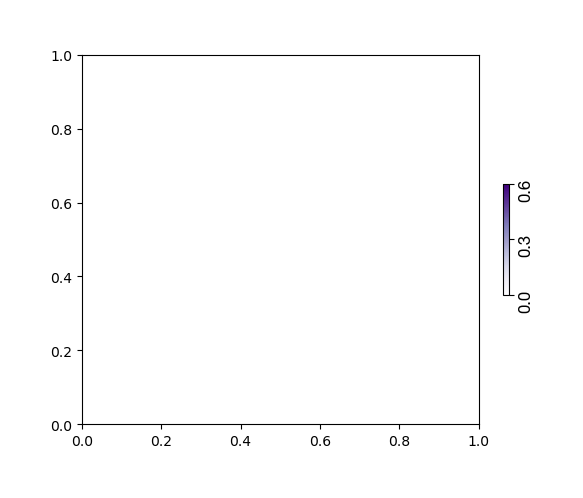

In [23]:
# SIDECHAIN_SHIFT_CBAR
mini=0
maxi=0.6
norm = colors.Normalize(vmin=mini, vmax=maxi)

cmp='Purples'


f2rgb2 = cm.ScalarMappable(norm=norm, cmap=cmp)
f2rgb2.set_array([])
tk=np.linspace(mini, maxi, 3)
tk=np.round(tk,2)
cbar=plt.colorbar(f2rgb2, ticks=tk,shrink=0.3)
cbar.ax.set_yticklabels(cbar.ax.get_yticklabels(), rotation=90,fontdict=font)


# plt.savefig('DIHEDRAL_SHIFT_UPON_MEM_BINDING/dot_hm_shift_cbar.png',
#                    dpi=450,transparent=True,
#                    bbox_inches='tight')

/var/folders/pp/z1pgcq157pjgg48m2cg7wwkh0000gn/T/ipykernel_81354/4264045484.py:9: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  cbar=plt.colorbar(f2rgb3, ticks=tk,shrink=0.3)


[Text(1, 0.0, '0.0'), Text(1, 0.3, '0.3'), Text(1, 0.6, '0.6')]

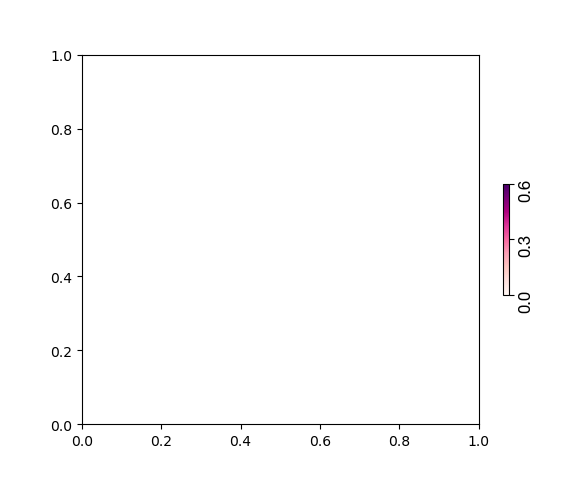

In [24]:
# BACKBONE_SHIFT_CBAR
cmp='RdPu'


f2rgb3 = cm.ScalarMappable(norm=norm, cmap=cmp)
f2rgb3.set_array([])
tk=np.linspace(mini, maxi, 3)
tk=np.round(tk,2)
cbar=plt.colorbar(f2rgb3, ticks=tk,shrink=0.3)
cbar.ax.set_yticklabels(cbar.ax.get_yticklabels(), rotation=90,fontdict=font)



In [25]:
def scaler(min_size, max_size, min_val, max_val, sizes):

    scaled_sizes = [(size - min_val) / (max_val - min_val) * (max_size - min_size) + min_size for size in sizes]

    return scaled_sizes




In [26]:
# MEM_RES=[1,2,3,4,5,6,7,8,9,10,12,36,37,38,39,40,41,42,43,44,46,80,82,84,85,112,114,115,116,117,118,119]
MEM_RES=[1, 2, 3, 4, 5, 6, 9, 10, 11, 12, 37, 38, 39, 40, 41, 42, 43, 45, 46, 119]
pock_res=[19,23,32,34,51,53,108,35,52,54,55,58,63,66,67,70]
rest_res=[i for i in range(1,120) if i not in MEM_RES+pock_res]



membrane_binding_region=[('N-Terminal',0,10),('B1',11,12),('L3',13,20),
                        ('B3',21,22),('L6',23,24),
                         ('B4',25,26),('C-Terminal',27,32)]
rest_region=[('H2',1,12),('L2',13,15),('B1',16,18),('L3',19,23),
            ('L4',24,26),('H3',27,33),('L5',34,42),('L6',44,53),('H4',54,61),
            ('L7',62,66),('B4',67,70)]
pockets_L=[('HP1',0,7),('HP2',8,15)]

def index_ret(segment, res_n):
    if segment=='MTM':
        return(MEM_RES.index(res_n))
    elif segment=='BPM':
        return(pock_res.index(res_n))
    elif segment=='REST':
        return(rest_res.index(res_n))
    

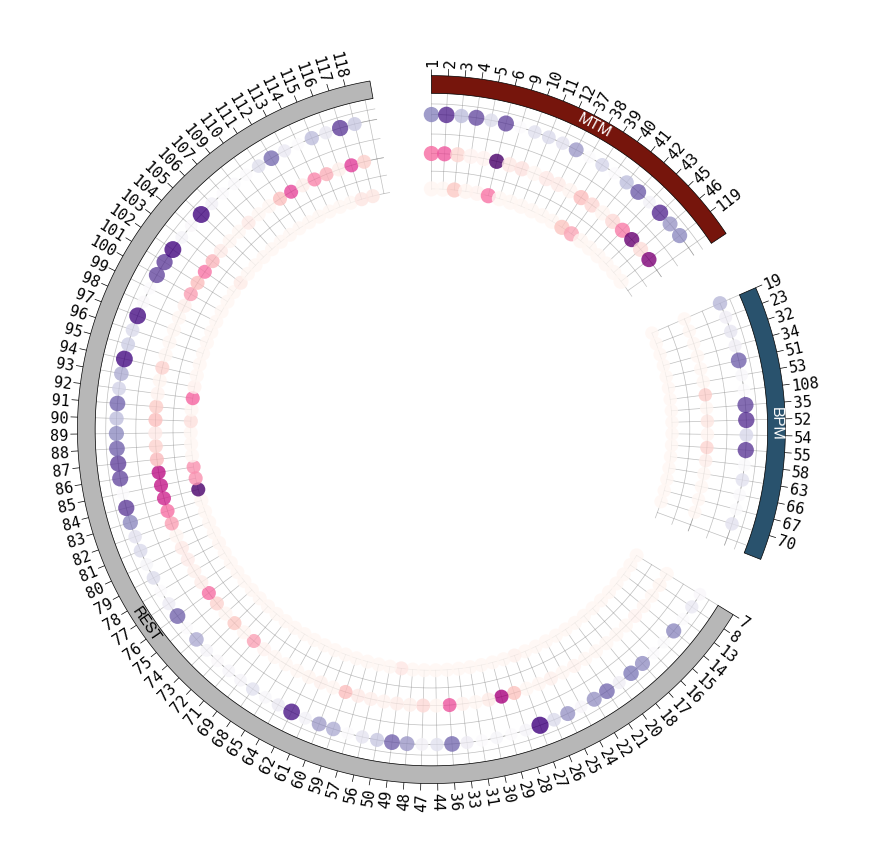

In [27]:
from pycirclize import Circos

sectors = {"MTM": len(MEM_RES)+0.6, "BPM": len(pock_res)+0.5,
          "REST":len(rest_res)+0.5,}
name2color = {"MTM": "#76150C","BPM":"#29526D","REST":"#B7B7B7",}
circos = Circos(sectors, sector2start_pos={"MEM_BINDING": 0,"POCKETS":0,
                                            "REST":0,},space=10)


c=0
for sector in circos.sectors:
    c=c+1
    if c==1:
        track = sector.add_track((100, 95),r_pad_ratio=0.5)
        track.axis(fc=name2color[sector.name])
        track.text(sector.name, color="white", size=11,
                   adjust_rotation=True,fontname="Helvetica Neue")

        track.xticks(x=[i for i in range (len(MEM_RES))],labels=[i for i in MEM_RES],
                    label_size=11,label_orientation='vertical',text_kws={'fontfamily':'monospace'})
c=0
for sector in circos.sectors:
    c=c+1
    if c==2:
        track = sector.add_track((100, 95),r_pad_ratio=0.5)
        track.axis(fc=name2color[sector.name])
        track.text(sector.name, color="white", size=11,fontname="Helvetica Neue")
        
        track.xticks(x=[i for i in range (len(pock_res))],labels=[i for i in pock_res],
                    label_size=11,label_orientation='vertical',text_kws={'fontfamily':'monospace'})
        
c=0
for sector in circos.sectors:
    c=c+1
    if c==3:
        track = sector.add_track((100, 95),r_pad_ratio=0.5)
        track.axis(fc=name2color[sector.name])
        track.text(sector.name, color="black", size=11,fontname="Helvetica Neue")
        
        track.xticks(x=[i for i in range (len(rest_res))],labels=[i for i in rest_res],
                    label_size=11,label_orientation='vertical',text_kws={'fontfamily':'monospace'})

        

for sel_range_ind, sel_range in enumerate([MEM_RES, pock_res, rest_res]):
    scatter_track = circos.sectors[sel_range_ind].add_track((89, 95), )

    x_ind_ls=[]
    col_ls=[]
    s_ls=[]
    for x_ind, x in enumerate(sel_range):
        fil_df=chi_shift_select_df[chi_shift_select_df['RESIDUES']==x]
        chi1_shift_val=fil_df['CHI1'].to_list()[0]

        col=f2rgb2.to_rgba(chi1_shift_val)[:3]
        col_ls.append(col)
        size_=scaler(80,150, 0,0.6,[chi1_shift_val])
        x_ind_ls.append(x_ind)
        s_ls.append(size_)
    scatter_track.scatter(x_ind_ls, [0 for i in x_ind_ls], color=col_ls, s=s_ls,
                         alpha=0.8)
    scatter_track.grid(y_grid_num=3, x_grid_interval=1, color="gray",lw=0.5)


    #bb_shift_data
    #----#
    scatter_track = circos.sectors[sel_range_ind].add_track((78, 89), )

    x_ind_ls=[]
    col_ls=[]
    s_ls=[]
    for x_ind, x in enumerate(sel_range):
        fil_df=bb_shift_data[bb_shift_data['Residues']==x]
        bb_shift_val=fil_df['psi shift'].to_list()[0]

        col=f2rgb3.to_rgba(bb_shift_val)[:3]
        col_ls.append(col)
        size_=scaler(80,150, 0,0.6,[chi1_shift_val])
        x_ind_ls.append(x_ind)
        s_ls.append(size_)

    scatter_track.scatter(x_ind_ls, [0 for i in x_ind_ls], color=col_ls, s=s_ls,
                         alpha=0.8)
    scatter_track.grid(y_grid_num=3, x_grid_interval=1, color="gray",lw=0.5)


    scatter_track = circos.sectors[sel_range_ind].add_track((78-10, 78), )

    x_ind_ls=[]
    col_ls=[]
    s_ls=[]
    for x_ind, x in enumerate(sel_range):
        fil_df=bb_shift_data[bb_shift_data['Residues']==x]
        bb_shift_val=fil_df['phi shift'].to_list()[0]

        col=f2rgb3.to_rgba(bb_shift_val)[:3]
        col_ls.append(col)
        size_=scaler(80,150, 0,0.6,[chi1_shift_val])
        x_ind_ls.append(x_ind)
        s_ls.append(size_)

    scatter_track.scatter(x_ind_ls, [0 for i in x_ind_ls], color=col_ls, s=s_ls,
                         alpha=0.8)
    scatter_track.grid(y_grid_num=3, x_grid_interval=1, color="gray",lw=0.5)









fig = circos.plotfig()


plt.savefig('../../../plots/dihedrals/rotamer_shift/BB_CHI1_dihedral_shift_pre_vs_unb.png', dpi=550,
           transparent=True, bbox_inches='tight')

In [10]:
# Region wise rotamer shift distribution

In [28]:
def region_rotamer_returner(shift_data, region_ls):
    shift_ls=[]
    for i in region_ls:
        shift_val=shift_data[i-1]
        shift_ls.append(shift_val)
    return shift_ls

In [29]:

max_chi=[]
for i,j,k,l in zip(chi_shift_select_df['CHI1'],
                  chi_shift_select_df['CHI2'],
                  chi_shift_select_df['CHI3'],
                  chi_shift_select_df['CHI4']):
    #max_chi.append(np.max([i,j,k,l]))
    max_chi.append(i) #considering chi1 only
    
mtm_chi_shift=region_rotamer_returner(max_chi, MEM_RES)
bp_chi_shift=region_rotamer_returner(max_chi, pock_res)
rest_chi_shift=region_rotamer_returner(max_chi, rest_res)


In [30]:
max_bb=bb_shift_data['Max'].to_list()

mtm_bb_shift=region_rotamer_returner(max_bb, MEM_RES)
bp_bb_shift=region_rotamer_returner(max_bb, pock_res)
rest_bb_shift=region_rotamer_returner(max_bb, rest_res)


In [31]:
shift_region_wise=pd.DataFrame()
shift_region_wise["Residue"]=MEM_RES+pock_res+rest_res
shift_region_wise['Region']=['MTM' for i in mtm_bb_shift]+['BP' for i in bp_bb_shift]+['REST' for i in rest_bb_shift]
shift_region_wise['BB_SHIFT']=mtm_bb_shift+ bp_bb_shift+ rest_bb_shift
shift_region_wise['SC_SHIFT']=mtm_chi_shift+ bp_chi_shift+ rest_chi_shift
shift_region_wise

,Residue,Region,BB_SHIFT,SC_SHIFT
0,1,MTM,0.297036,0.357198
1,2,MTM,0.324675,0.521257
2,3,MTM,0.137196,0.224220
3,4,MTM,0.013653,0.456654
4,5,MTM,0.012987,0.138972
...,...,...,...,...
114,114,REST,0.258408,0.000000
115,115,REST,0.190143,0.220890
116,116,REST,0.026307,0.098124
117,117,REST,0.360972,0.484404


In [32]:
shift_region_wise.to_csv("../../../../LC3_paper_data_files_for_source_data_comp/rotamer_shift_pre_vs_unb.csv")


/var/folders/pp/z1pgcq157pjgg48m2cg7wwkh0000gn/T/ipykernel_81354/3568342044.py:15: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(x='Region', y='BB_SHIFT', data=shift_region_wise,
/Users/jesucastin/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/jesucastin/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/jesucastin/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of panda

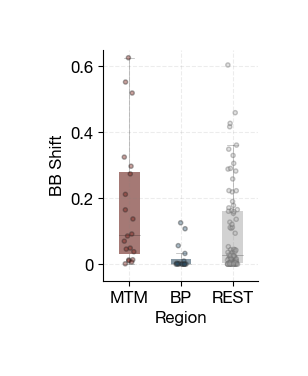

In [39]:
# Create the boxplot
fig, ax = plt.subplots(figsize=(2,3))
PROPS = {
    'boxprops':{ 'edgecolor':'none', 'alpha':0.6},
    'medianprops':{'color':'black','alpha':0.3},
    'whiskerprops':{'color':'black','alpha':0.3},
    'capprops':{'color':'black','alpha':0.3}}
# col_ls=['#63C2A7','#EDBE1F','#B8BAC0' ]
col_ls=["#76150C","#29526D","#B4B4B4"]

sns.boxplot(x='Region', y='BB_SHIFT', data=shift_region_wise, 
            showfliers=False,width=0.4,palette=col_ls,
            **PROPS,ax=ax)

sns.stripplot(x='Region', y='BB_SHIFT', data=shift_region_wise, 
              jitter=True, alpha=0.4, 
              dodge=False, palette=col_ls,
              size=3,linewidth=1,ax=ax)



ax.yaxis.grid(color='gray', linestyle='dashed',alpha=0.15)
ax.xaxis.grid(color='gray', linestyle='dashed',alpha=0.15)

#ax.tick_params(labelsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_xticks([0,1,2], ['MTM', 'BP', 'REST'])
ax.set_xticklabels(['MTM', 'BP', 'REST'], fontdict=font)

ax.set_yticks([0,0.2,0.4,0.6], [0,0.2,0.4,0.6])
ax.set_yticklabels([0,0.2,0.4,0.6], fontdict=font)


ax.set_xlabel('Region', fontdict=font)
ax.set_ylabel('BB Shift', fontdict=font)

ax.set_ylim(-0.05,0.65)


plt.savefig('../../../plots/dihedrals/rotamer_shift/BB_SHIFT_pre_vs_unb_regionwise.png', dpi=550,
           transparent=True, bbox_inches='tight')

/var/folders/pp/z1pgcq157pjgg48m2cg7wwkh0000gn/T/ipykernel_81354/112223238.py:15: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(x='Region', y='SC_SHIFT', data=shift_region_wise,
/Users/jesucastin/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/jesucastin/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/jesucastin/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas

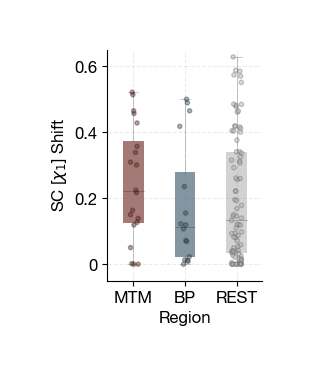

In [40]:
# Create the boxplot
fig, ax = plt.subplots(figsize=(2,3))
PROPS = {
    'boxprops':{ 'edgecolor':'none', 'alpha':0.6},
    'medianprops':{'color':'black','alpha':0.3},
    'whiskerprops':{'color':'black','alpha':0.3},
    'capprops':{'color':'black','alpha':0.3}}
# col_ls=['#63C2A7','#EDBE1F','#B8BAC0' ]
col_ls=["#76150C","#29526D","#B4B4B4"]

sns.boxplot(x='Region', y='SC_SHIFT', data=shift_region_wise, 
            showfliers=False,width=0.4,palette=col_ls,
            **PROPS,ax=ax)

sns.stripplot(x='Region', y='SC_SHIFT', data=shift_region_wise, 
              jitter=True, alpha=0.4, 
              dodge=False, palette=col_ls,
              size=3,linewidth=1,ax=ax)



ax.yaxis.grid(color='gray', linestyle='dashed',alpha=0.15)
ax.xaxis.grid(color='gray', linestyle='dashed',alpha=0.15)

#ax.tick_params(labelsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_xticks([0,1,2], ['MTM', 'BP', 'REST'])
ax.set_xticklabels(['MTM', 'BP', 'REST'], fontdict=font)

ax.set_yticks([0,0.2,0.4,0.6], [0,0.2,0.4,0.6])
ax.set_yticklabels([0,0.2,0.4,0.6], fontdict=font)


ax.set_xlabel('Region', fontdict=font)
ax.set_ylabel('SC [$\chi_1$] Shift', fontdict=font)

ax.set_ylim(-0.05,0.65)

plt.savefig('../../../plots/dihedrals/rotamer_shift/CHI1_SHIFT_pre_vs_unb_regionwise.png', dpi=550,
           transparent=True, bbox_inches='tight')

In [37]:
(shift_region_wise[shift_region_wise["Region"]=="REST"]["BB_SHIFT"]>=0.2).astype(int).sum()/\
len(shift_region_wise[shift_region_wise["Region"]=="REST"]["BB_SHIFT"])


0.18072289156626506

In [38]:
(shift_region_wise[shift_region_wise["Region"]=="REST"]["SC_SHIFT"]>=0.2).astype(int).sum()/\
len(shift_region_wise[shift_region_wise["Region"]=="REST"]["SC_SHIFT"])


0.39759036144578314